# Stance Detection — Results Analysis
**Dataset:** SemEval 2016 Task 6 — 1,249 test documents · 5 targets
*(Atheism, Climate Change, Feminist Movement, Hillary Clinton, Legalization of Abortion)*
**Task:** 3-class stance classification (FAVOR / AGAINST / NONE)
**Primary metric:** Macro-F1 (unweighted mean across all three classes)

---

### Research Questions
1. How does prompt complexity affect performance across models?
2. At what model size does stance detection become practically useful?
3. Does adding more few-shot examples reliably improve performance?
4. Does framing stance as a 5-point scale improve over direct classification?
5. How consistently do models agree with each other?

In [49]:
from pathlib import Path
import re
from itertools import combinations
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_recall_fscore_support, cohen_kappa_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.35,
})
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

In [50]:
RUNS_ROOT = Path('../data_out/semeval2016_task6_testdata_gold')
LABELS    = ['FAVOR', 'AGAINST', 'NONE']
RNG       = np.random.default_rng(42)

# ── Prompt complexity ordering (simplest → most complex) ──────────────────
#    Zero-shot tier: no instructions → basic → task definition → question framing → CoT
#    Few-shot tier:  3 → 6 → 9 → 12 examples
#    Separate:       5-point scale reformulation
ZERO_SHOT_ORDER = [
    'default_no_label_definitions',
    'default',
    'task_definition',
    'question',
    'cot',
    'few_shot',          # original fixed few-shot (≈3 examples)
]
FEW_SHOT_SCALE  = ['few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12']
ALL_PROMPTS     = ZERO_SHOT_ORDER + FEW_SHOT_SCALE + ['task_definition_scale']

PROMPT_LABELS = {
    'default_no_label_definitions': 'No defs',
    'default':                      'Default',
    'task_definition':              'Task def',
    'question':                     'Question',
    'cot':                          'CoT',
    'few_shot':                     'Few-shot',
    'few_shot_3':                   '3-shot',
    'few_shot_6':                   '6-shot',
    'few_shot_9':                   '9-shot',
    'few_shot_12':                  '12-shot',
    'task_definition_scale':        'Scale',
}

# ── Model metadata ─────────────────────────────────────────────────────────
MODEL_SIZES = {                             # parameters in billions
    'Qwen3-1.7B':                    1.7,
    'phi-4-mini-instruct':           3.8,
    'Nemotron-Mini-4B-Instruct':     4.0,
    'Qwen3-4B':                      4.0,
    'Qwen3-4B-Instruct-2507':        4.0,
    'Llama-3.1-8B-Instruct':         8.0,
    'DeepSeek-R1-Distill-Llama-8B':  8.0,
    'Qwen3-8B':                      8.0,
    'DeepSeek-R1-Distill-Qwen-14B': 14.0,
    'Qwen3-14B':                    14.0,
    'phi-4':                        14.0,
    'DeepSeek-R1-Distill-Qwen-32B': 32.0,
    'Qwen3-32B':                    32.0,
    # gpt-5-mini, gpt-5.2: closed-source, sizes not disclosed
}

MODEL_FAMILY = {
    'Qwen3-1.7B':                   'Qwen3',
    'Qwen3-4B':                     'Qwen3',
    'Qwen3-4B-Instruct-2507':       'Qwen3',
    'Qwen3-8B':                     'Qwen3',
    'Qwen3-14B':                    'Qwen3',
    'Qwen3-32B':                    'Qwen3',
    'Llama-3.1-8B-Instruct':        'Llama',
    'DeepSeek-R1-Distill-Llama-8B': 'DeepSeek-R1',
    'DeepSeek-R1-Distill-Qwen-14B': 'DeepSeek-R1',
    'DeepSeek-R1-Distill-Qwen-32B': 'DeepSeek-R1',
    'Nemotron-Mini-4B-Instruct':    'Nemotron',
    'phi-4-mini-instruct':          'Phi',
    'phi-4':                        'Phi',
    'gpt-5-mini':                   'GPT-5',
    'gpt-5.2':                      'GPT-5',
}

FAMILY_COLORS = {
    'Qwen3':       '#4C78A8',
    'DeepSeek-R1': '#F58518',
    'Llama':       '#72B7B2',
    'Nemotron':    '#76B900',
    'Phi':         '#E45756',
    'GPT-5':       '#54A24B',
    'Other':       '#B279A2',
}

SEMEVAL_BASELINE = 0.69  # best published baseline on SemEval 2016 Task 6
F1_USABLE    = 0.55   # practical minimum threshold

In [51]:
def parse_run_folder(name: str):
    m = re.match(r'.*semeval2016_task6_testdata_gold_(.+)_equal_(.+)$', name)
    return (m.group(1), m.group(2)) if m else None

def norm_label(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if 'FAVOR'   in s: return 'FAVOR'
    if 'AGAINST' in s: return 'AGAINST'
    if s in {'NONE', 'NEITHER', 'NEUTRAL'}: return 'NONE'
    return s

def model_sort_key(model):
    """Sort key: size (asc) → family → name.  Closed-source goes last."""
    return (MODEL_SIZES.get(model, 999), MODEL_FAMILY.get(model, 'zzz'), model)

def family_color(model):
    return FAMILY_COLORS.get(MODEL_FAMILY.get(model, 'Other'), '#888888')

def build_model_colors(models):
    """Return {model: hex_color} with distinct lightness shades within each family.

    Models in the same family share the same hue but are spread across
    lightness values so they remain visually distinguishable.
    """
    import colorsys
    import matplotlib.colors as mc
    from collections import defaultdict

    family_members = defaultdict(list)
    for m in models:
        family_members[MODEL_FAMILY.get(m, 'Other')].append(m)

    result = {}
    for fam, members in family_members.items():
        base = FAMILY_COLORS.get(fam, '#888888')
        h, l, s = colorsys.rgb_to_hls(*mc.to_rgb(base))
        n = len(members)
        if n == 1:
            result[members[0]] = base
        else:
            # spread lightness from 0.28 (dark) to 0.62 (light)
            lums = np.linspace(0.28, 0.62, n)
            for m, lum in zip(members, lums):
                result[m] = mc.to_hex(colorsys.hls_to_rgb(h, lum, s))
    return result


In [52]:
run_files = sorted(RUNS_ROOT.glob('*/document_assignments.csv'))
if not run_files:
    raise FileNotFoundError(f'No run files found under {RUNS_ROOT}')

system_frames = {}
meta_rows     = []

for fp in run_files:
    parsed = parse_run_folder(fp.parent.name)
    if parsed is None:
        continue
    model, prompt = parsed

    df = pd.read_csv(fp)
    needed = {'doc_id', 'original_stance', 'predicted_stance'}
    if needed - set(df.columns):
        continue

    cols = ['doc_id', 'original_stance', 'predicted_stance']
    if 'query' in df.columns:
        cols.append('query')

    df = df[cols].copy()
    df['doc_id'] = df['doc_id'].astype(str)
    df['gold']   = df['original_stance'].map(norm_label)
    df['pred']   = df['predicted_stance'].map(norm_label)

    n_total    = len(df)
    n_parseable = df['pred'].isin(LABELS).sum()
    parse_fail = 1.0 - n_parseable / n_total

    df = df[df['gold'].isin(LABELS) & df['pred'].isin(LABELS)].copy()

    system = f'{model} | {prompt}'
    system_frames[system] = df
    meta_rows.append({
        'system':      system,
        'model':       model,
        'prompt':      prompt,
        'family':      MODEL_FAMILY.get(model, 'Other'),
        'size_B':      MODEL_SIZES.get(model),
        'parse_fail':  round(parse_fail * 100, 2),
        'n_total':     n_total,
        'n_eval':      len(df),
    })

meta_df = pd.DataFrame(meta_rows).sort_values(['model', 'prompt'])
print(f'Systems loaded : {len(system_frames)}')
print(f'Models         : {meta_df["model"].nunique()}')
print(f'Prompts        : {sorted(meta_df["prompt"].unique())}')

Systems loaded : 143
Models         : 13
Prompts        : ['cot', 'default', 'default_no_label_definitions', 'few_shot', 'few_shot_12', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'question', 'task_definition', 'task_definition_scale']


In [53]:
metric_rows = []
for _, m in meta_df.iterrows():
    d  = system_frames[m['system']]
    yt = d['gold'].values
    yp = d['pred'].values
    p, r, f, sup = precision_recall_fscore_support(yt, yp, labels=LABELS, zero_division=0)
    metric_rows.append({
        **m.to_dict(),
        'macro_f1':      f1_score(yt, yp, labels=LABELS, average='macro',    zero_division=0),
        'accuracy':      accuracy_score(yt, yp),
        'f1_FAVOR':   f[0], 'f1_AGAINST': f[1], 'f1_NONE': f[2],
        'support_FAVOR': sup[0], 'support_AGAINST': sup[1], 'support_NONE': sup[2],
    })

metrics = pd.DataFrame(metric_rows)
metrics['prompt_label'] = metrics['prompt'].map(PROMPT_LABELS).fillna(metrics['prompt'])
metrics['size_label']   = metrics['size_B'].apply(
    lambda x: f'{x:g}B' if pd.notna(x) else 'closed'
)

# ── Summary table ──────────────────────────────────────────────────────────
overview = (
    metrics.groupby(['model', 'family', 'size_B', 'size_label'], dropna=False)
    .agg(
        best_macro_f1      = ('macro_f1',    'max'),
        mean_macro_f1      = ('macro_f1',    'mean'),
        mean_parse_fail_pct= ('parse_fail',  'mean'),
        n_prompts          = ('prompt',      'nunique'),
    )
    .reset_index()
    .sort_values('size_B', na_position='last')
    .round({'best_macro_f1': 3, 'mean_macro_f1': 3, 'mean_parse_fail_pct': 2})
)
overview['useful'] = overview['best_macro_f1'] >= F1_USABLE

display(overview[['model', 'family', 'size_label',
                   'best_macro_f1', 'mean_macro_f1', 'mean_parse_fail_pct', 'useful']])

,model,family,size_label,best_macro_f1,mean_macro_f1,mean_parse_fail_pct,useful
4,Qwen3-1.7B,Qwen3,1.7B,0.465,0.342,0.020,False
12,phi-4-mini-instruct,Phi,3.8B,0.596,0.570,0.000,True
3,Nemotron-Mini-4B-Instruct,Nemotron,4B,0.633,0.509,0.000,True
6,Qwen3-4B,Qwen3,4B,0.654,0.601,0.710,True
7,Qwen3-4B-Instruct-2507,Qwen3,4B,0.671,0.625,0.000,True
0,DeepSeek-R1-Distill-Llama-8B,DeepSeek-R1,8B,0.585,0.560,0.020,True
2,Llama-3.1-8B-Instruct,Llama,8B,0.609,0.539,0.000,True
8,Qwen3-8B,Qwen3,8B,0.687,0.603,0.580,True
1,DeepSeek-R1-Distill-Qwen-14B,DeepSeek-R1,14B,0.662,0.635,0.010,True
5,Qwen3-14B,Qwen3,14B,0.638,0.595,0.060,True


## 1 · Prompt Complexity Effect on Performance

How does adding more information/instruction to the prompt change model behaviour?
Prompts are ordered left-to-right from simplest (no label definitions) to most complex (12 in-context examples).
The 5-point scale reformulation (`Scale`) is shown as a separate column on the right.

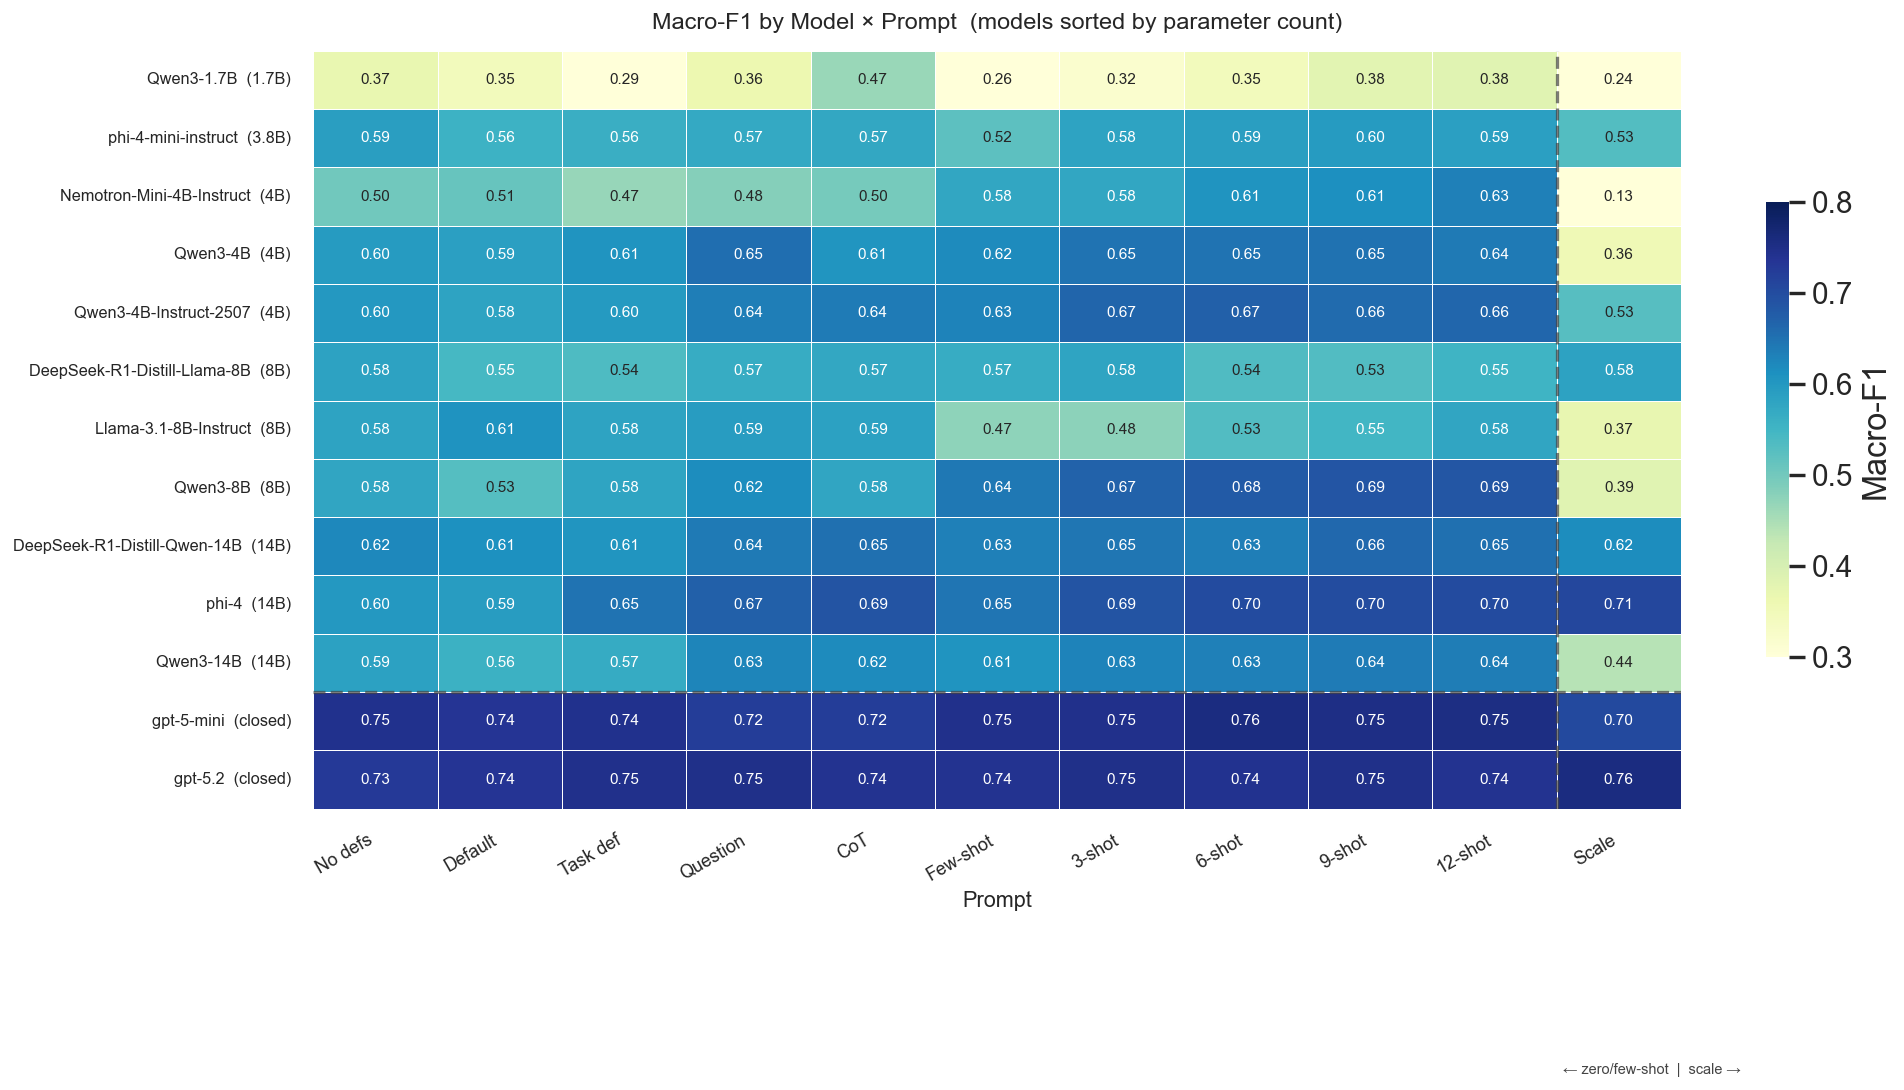

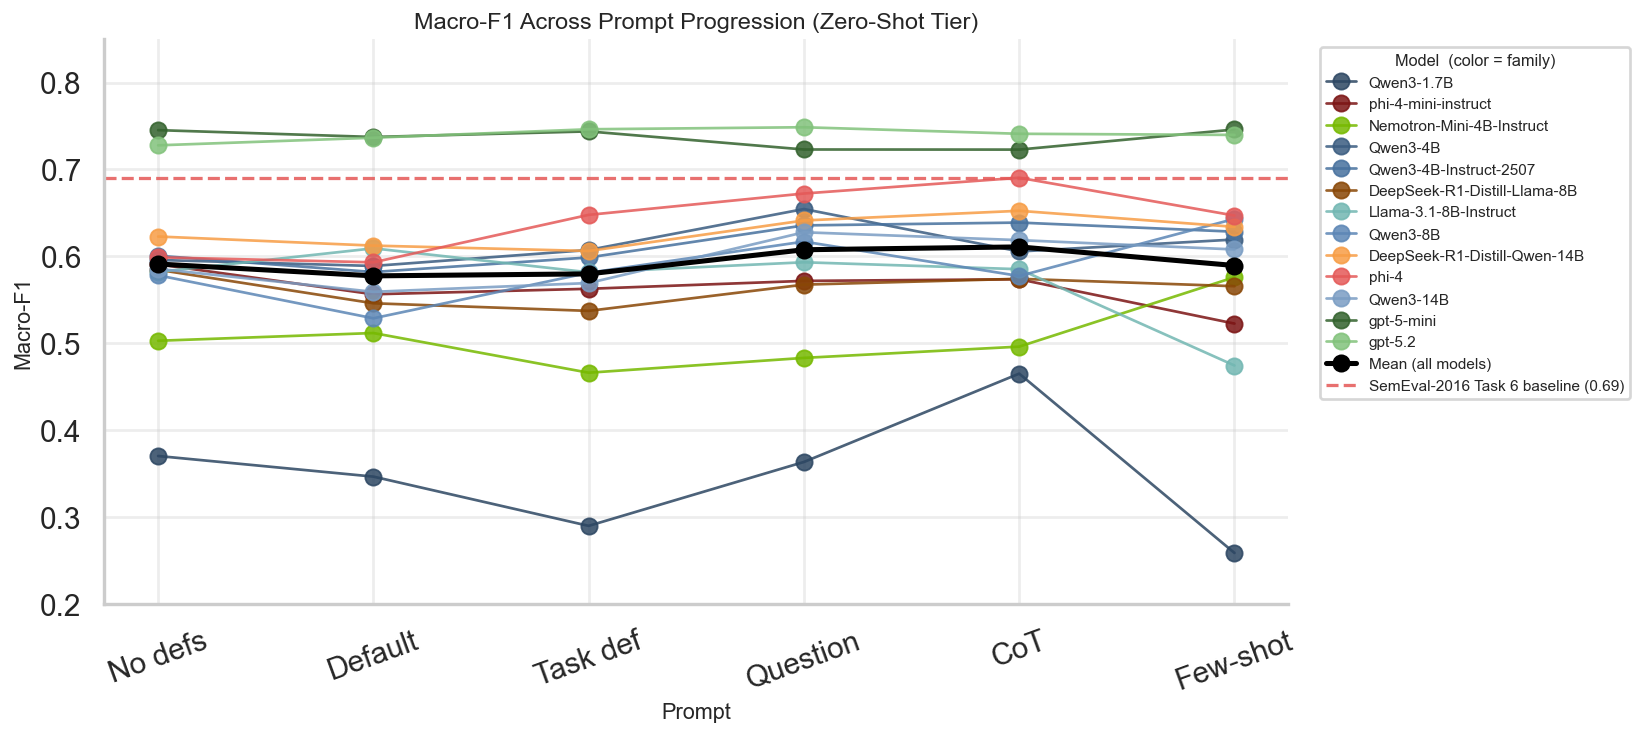

In [54]:
available_prompts = set(metrics['prompt'].unique())
ordered_labels = [PROMPT_LABELS[p] for p in ALL_PROMPTS if p in available_prompts]
ordered_models = sorted(metrics['model'].unique(), key=model_sort_key)

pivot_f1 = (
    metrics
    .assign(pl=lambda d: d['prompt'].map(PROMPT_LABELS).fillna(d['prompt']))
    .pivot_table(index='model', columns='pl', values='macro_f1', aggfunc='mean')
    .reindex(index=ordered_models, columns=ordered_labels)
)

# Row-level annotations: size label
row_labels = [
    f"{m}  ({MODEL_SIZES[m]:g}B)" if m in MODEL_SIZES else f"{m}  (closed)"
    for m in ordered_models
]

fig, ax = plt.subplots(figsize=(16, 0.55 * len(ordered_models) + 2))
sns.heatmap(
    pivot_f1,
    annot=True, fmt='.2f',
    cmap='YlGnBu', vmin=0.30, vmax=0.80,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8.5},
    ax=ax,
    cbar_kws={'label': 'Macro-F1', 'shrink': 0.6},
)
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_xlabel('Prompt', fontsize=12)
ax.set_ylabel('')

# Vertical separator before Scale column
scale_idx = ordered_labels.index('Scale') if 'Scale' in ordered_labels else None
if scale_idx is not None:
    ax.axvline(x=scale_idx, color='#444', linewidth=1.8, linestyle='--', alpha=0.7)
    ax.text(scale_idx + 0.05, -0.35, '← zero/few-shot  |  scale →',
            transform=ax.get_xaxis_transform(), fontsize=8, color='#444')

# Horizontal separator before GPT-5 rows (closed-source)
closed_start = next(
    (i for i, m in enumerate(ordered_models) if MODEL_FAMILY.get(m) == 'GPT-5'), None
)
if closed_start is not None:
    ax.axhline(y=closed_start, color='#444', linewidth=1.8, linestyle='--', alpha=0.7)

ax.set_title('Macro-F1 by Model × Prompt  (models sorted by parameter count)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# ── Line chart: prompt progression per model (zero-shot tier) ─────────────
zs_avail = [p for p in ZERO_SHOT_ORDER if p in available_prompts]
zs_label_avail = [PROMPT_LABELS[p] for p in zs_avail]
zs_data = metrics[metrics['prompt'].isin(zs_avail)].copy()
zs_data['prompt_label'] = pd.Categorical(
    zs_data['prompt'].map(PROMPT_LABELS),
    categories=zs_label_avail, ordered=True
)

fig, ax = plt.subplots(figsize=(13, 6))
# per-model distinct shades (same hue as family, varied lightness)
model_colors = build_model_colors(sorted(zs_data['model'].unique(), key=model_sort_key))
for model in sorted(zs_data['model'].unique(), key=model_sort_key):
    sub = zs_data[zs_data['model'] == model].sort_values('prompt_label')
    color = model_colors[model]
    size  = MODEL_SIZES.get(model)
    lw    = 1.5 if size and size >= 14 else 1.5
    ls    = '-' if MODEL_FAMILY.get(model) == 'GPT-5' else '-'
    ax.plot(sub['prompt_label'].astype(str), sub['macro_f1'],
            marker='o', color=color, linewidth=lw, linestyle=ls, alpha=0.85, label=model)

# Mean trajectory
mean_traj = zs_data.groupby('prompt_label', observed=True)['macro_f1'].mean().reindex(zs_label_avail)
ax.plot(zs_label_avail, mean_traj.values,
        marker='o', color='black', linewidth=2.8, linestyle='-', label='Mean (all models)', zorder=5)

ax.axhline(SEMEVAL_BASELINE, color='#E45756', linewidth=1.8, linestyle='--', alpha=0.85,
           label=f'SemEval-2016 Task 6 baseline ({SEMEVAL_BASELINE})')
ax.set_ylim(0.2, 0.85)
ax.set_xlabel('Prompt', fontsize=12)
ax.set_ylabel('Macro-F1', fontsize=12)
ax.set_title('Macro-F1 Across Prompt Progression (Zero-Shot Tier)', fontsize=13)
ax.tick_params(axis='x', rotation=20)

# Legend: individual model names (colored by family) + reference lines
model_handles, model_labels = ax.get_legend_handles_labels()
# Separate model entries from reference lines (mean + baseline added last)
ref_labels  = {'Mean (all models)', f'SemEval-2016 Task 6 baseline ({SEMEVAL_BASELINE})'}
m_handles   = [h for h, l in zip(model_handles, model_labels) if l not in ref_labels]
m_labels    = [l for l in model_labels if l not in ref_labels]
ref_handles = [h for h, l in zip(model_handles, model_labels) if l in ref_labels]
ref_lbls    = [l for l in model_labels if l in ref_labels]

ax.legend(
    handles=m_handles + ref_handles,
    labels=m_labels + ref_lbls,
    title='Model  (color = family)',
    fontsize=8.5, title_fontsize=9,
    bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
)
plt.tight_layout()
plt.show()

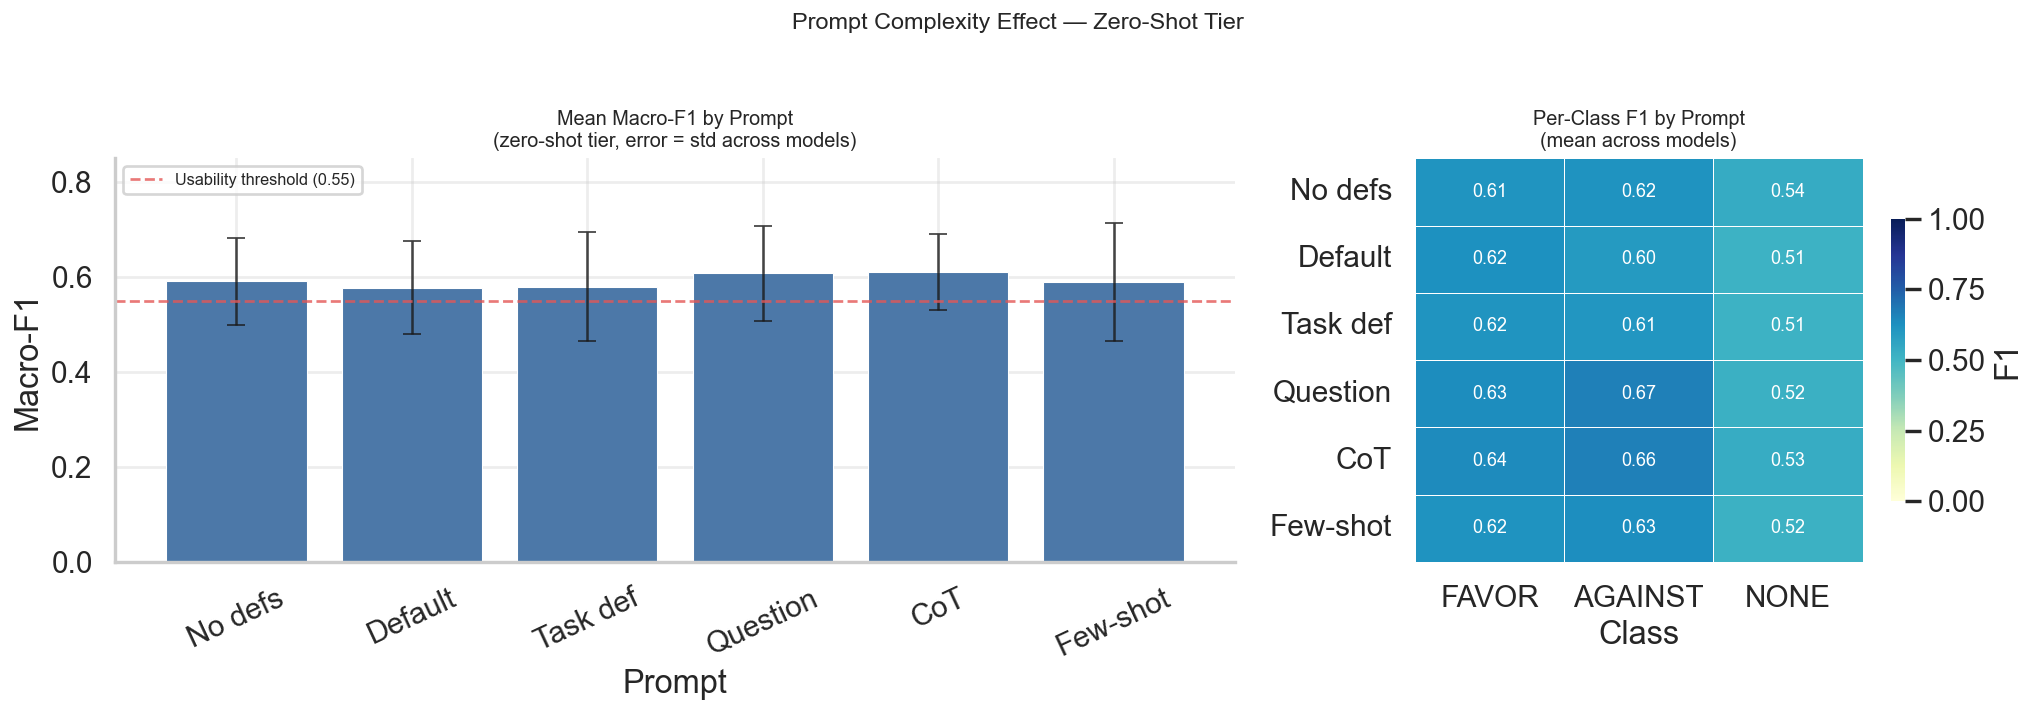

In [55]:
zero_shot_labels = [PROMPT_LABELS[p] for p in ZERO_SHOT_ORDER if p in available_prompts]
few_shot_labels  = [PROMPT_LABELS[p] for p in FEW_SHOT_SCALE  if p in available_prompts]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [2, 1]})

# ── Left: mean F1 ± std per prompt (zero-shot tier only) ──────────────────
zs_metrics = metrics[metrics['prompt'].isin(ZERO_SHOT_ORDER)].copy()
zs_metrics['prompt_label'] = pd.Categorical(
    zs_metrics['prompt'].map(PROMPT_LABELS), categories=zero_shot_labels, ordered=True
)
agg = (
    zs_metrics.groupby('prompt_label', observed=True)
    .agg(mean=('macro_f1', 'mean'), std=('macro_f1', 'std'))
    .reset_index()
)
colors = [('#4C78A8' if v >= F1_USABLE else '#d3d3d3') for v in agg['mean']]
axes[0].bar(agg['prompt_label'], agg['mean'], yerr=agg['std'],
            color=colors, capsize=5, error_kw={'elinewidth': 1.4, 'alpha': 0.8},
            edgecolor='white', linewidth=0.6)
axes[0].axhline(F1_USABLE, color='#E45756', linewidth=1.5, linestyle='--', alpha=0.8,
                label=f'Usability threshold ({F1_USABLE})')
axes[0].set_ylim(0, 0.85)
axes[0].set_title('Mean Macro-F1 by Prompt\n(zero-shot tier, error = std across models)', fontsize=11)
axes[0].set_xlabel('Prompt')
axes[0].set_ylabel('Macro-F1')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(fontsize=9, loc='upper left')

# ── Right: per-class F1 heatmap ────────────────────────────────────────────
class_cols = ['f1_FAVOR', 'f1_AGAINST', 'f1_NONE']
class_agg  = (
    zs_metrics.groupby('prompt_label', observed=True)[class_cols]
    .mean()
    .reindex(zero_shot_labels)
    .rename(columns={'f1_FAVOR': 'FAVOR', 'f1_AGAINST': 'AGAINST', 'f1_NONE': 'NONE'})
)
sns.heatmap(class_agg, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5,
            annot_kws={'size': 10},
            cbar_kws={'label': 'F1', 'shrink': 0.7})
axes[1].set_title('Per-Class F1 by Prompt\n(mean across models)', fontsize=11)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Prompt Complexity Effect — Zero-Shot Tier', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2 · Model Size vs. Performance

Does larger always mean better?
We plot each model's **best macro-F1** (across all prompts) against its parameter count.
The dashed line marks the practical usability threshold (macro-F1 = 0.55).
GPT-5 models are shown separately on the right since their sizes are not publicly disclosed.

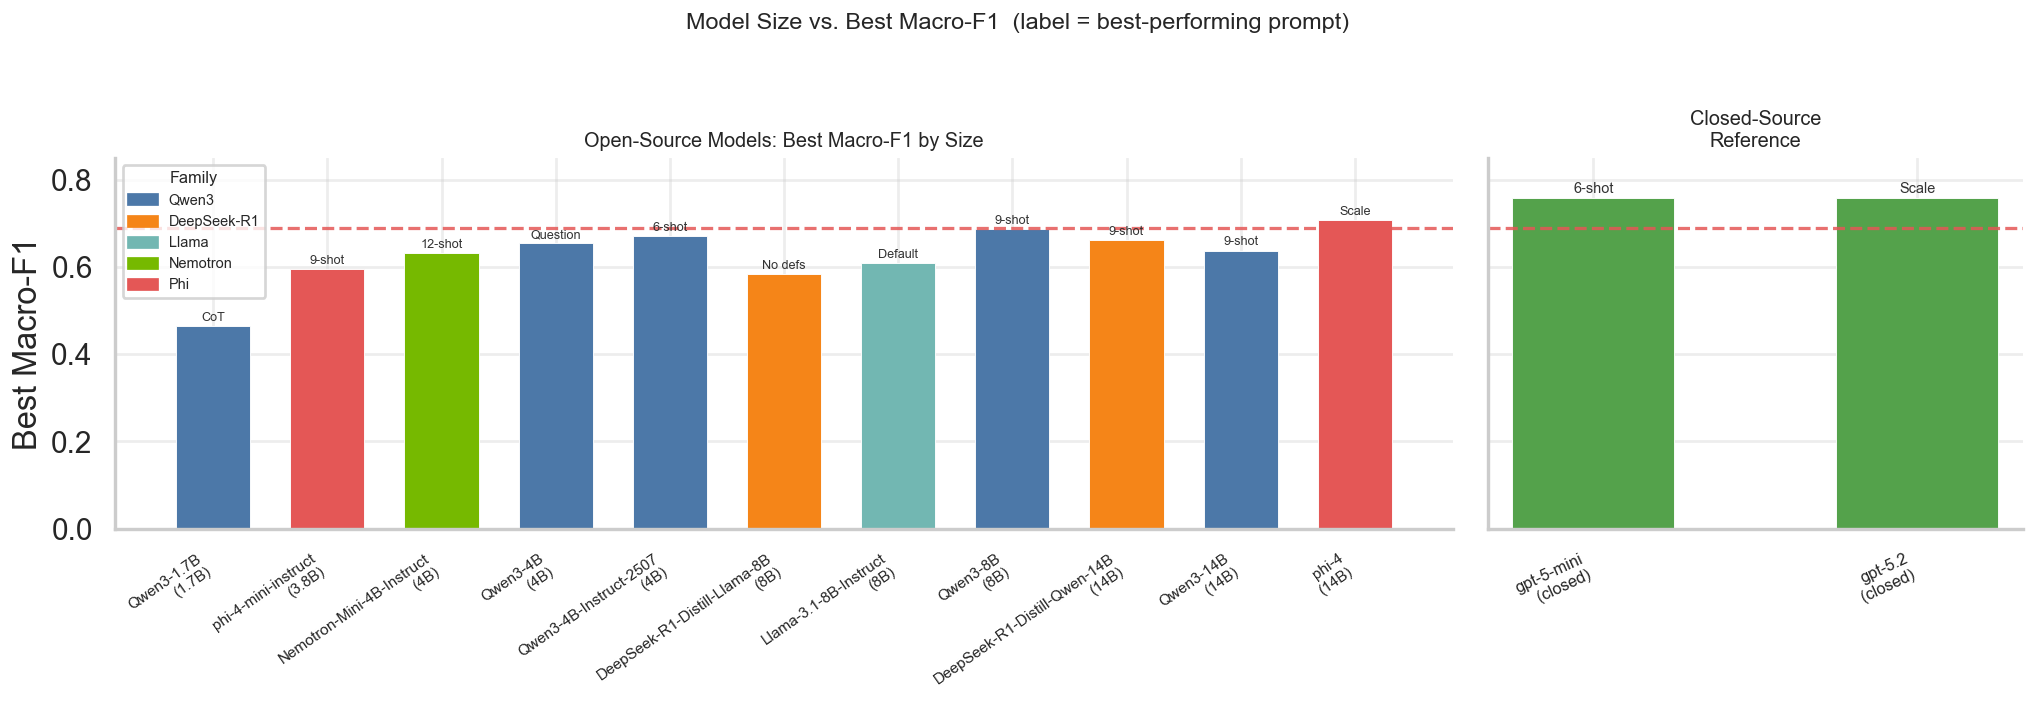

In [56]:
best_per_model = (
    metrics.groupby(['model', 'family', 'size_B', 'size_label'], dropna=False)
    .agg(best_f1=('macro_f1', 'max'), best_prompt=('macro_f1', 'idxmax'))
    .reset_index()
)
best_per_model['best_prompt_name'] = best_per_model['best_prompt'].map(
    lambda idx: metrics.loc[idx, 'prompt'] if idx in metrics.index else ''
)
open_src  = best_per_model[best_per_model['size_B'].notna()].sort_values('size_B')
closed    = best_per_model[best_per_model['size_B'].isna()].sort_values('model')

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5),
                          gridspec_kw={'width_ratios': [2.5, 1]},
                          sharey=True)

# ── Left: open-source — bar chart sorted by size ─────────────────────────
ax = axes[0]
x_vals = range(len(open_src))
bar_colors = [FAMILY_COLORS.get(f, '#888') for f in open_src['family']]
bars = ax.bar(x_vals, open_src['best_f1'], color=bar_colors,
              edgecolor='white', linewidth=0.5, width=0.65)
ax.axhline(SEMEVAL_BASELINE, color='#E45756', linewidth=1.8, linestyle='--',
           label=f'SemEval-2016 baseline ({SEMEVAL_BASELINE})', alpha=0.85)
ax.set_xticks(x_vals)
ax.set_xticklabels(
    [f"{r['model']}\n({r['size_label']})" for _, r in open_src.iterrows()],
    rotation=35, ha='right', fontsize=8.5
)
ax.set_ylabel('Best Macro-F1')
ax.set_ylim(0.0, 0.85)
ax.set_title('Open-Source Models: Best Macro-F1 by Size', fontsize=11)
ax.legend(fontsize=9)

# Annotate best-prompt per bar
for bar, (_, row) in zip(bars, open_src.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            PROMPT_LABELS.get(row['best_prompt_name'], row['best_prompt_name']),
            ha='center', va='bottom', fontsize=7, color='#333')

# Family legend patches
handles = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()
           if f in open_src['family'].values]
ax.legend(handles=handles, title='Family', fontsize=8, title_fontsize=9,
          loc='upper left', frameon=True)

# ── Right: closed-source ──────────────────────────────────────────────────
ax2 = axes[1]
x2  = range(len(closed))
bar_colors2 = [FAMILY_COLORS.get(f, '#888') for f in closed['family']]
ax2.bar(x2, closed['best_f1'], color=bar_colors2,
        edgecolor='white', linewidth=0.5, width=0.5)
ax2.axhline(SEMEVAL_BASELINE, color='#E45756', linewidth=1.8, linestyle='--', alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels(
    [f"{r['model']}\n(closed)" for _, r in closed.iterrows()],
    rotation=25, ha='right', fontsize=9
)
ax2.set_title('Closed-Source\nReference', fontsize=11)

for bar, (_, row) in zip(ax2.patches, closed.iterrows()):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             PROMPT_LABELS.get(row['best_prompt_name'], row['best_prompt_name']),
             ha='center', va='bottom', fontsize=8, color='#333')

plt.suptitle('Model Size vs. Best Macro-F1  (label = best-performing prompt)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3 · Few-Shot Scaling (3 → 12 In-Context Examples)

Does providing more labelled examples consistently improve performance?
We compare 3-shot through 12-shot across all models.
Statistical significance tested with Kendall's τ per model (only 4 data points per model, so treat trends as indicative).

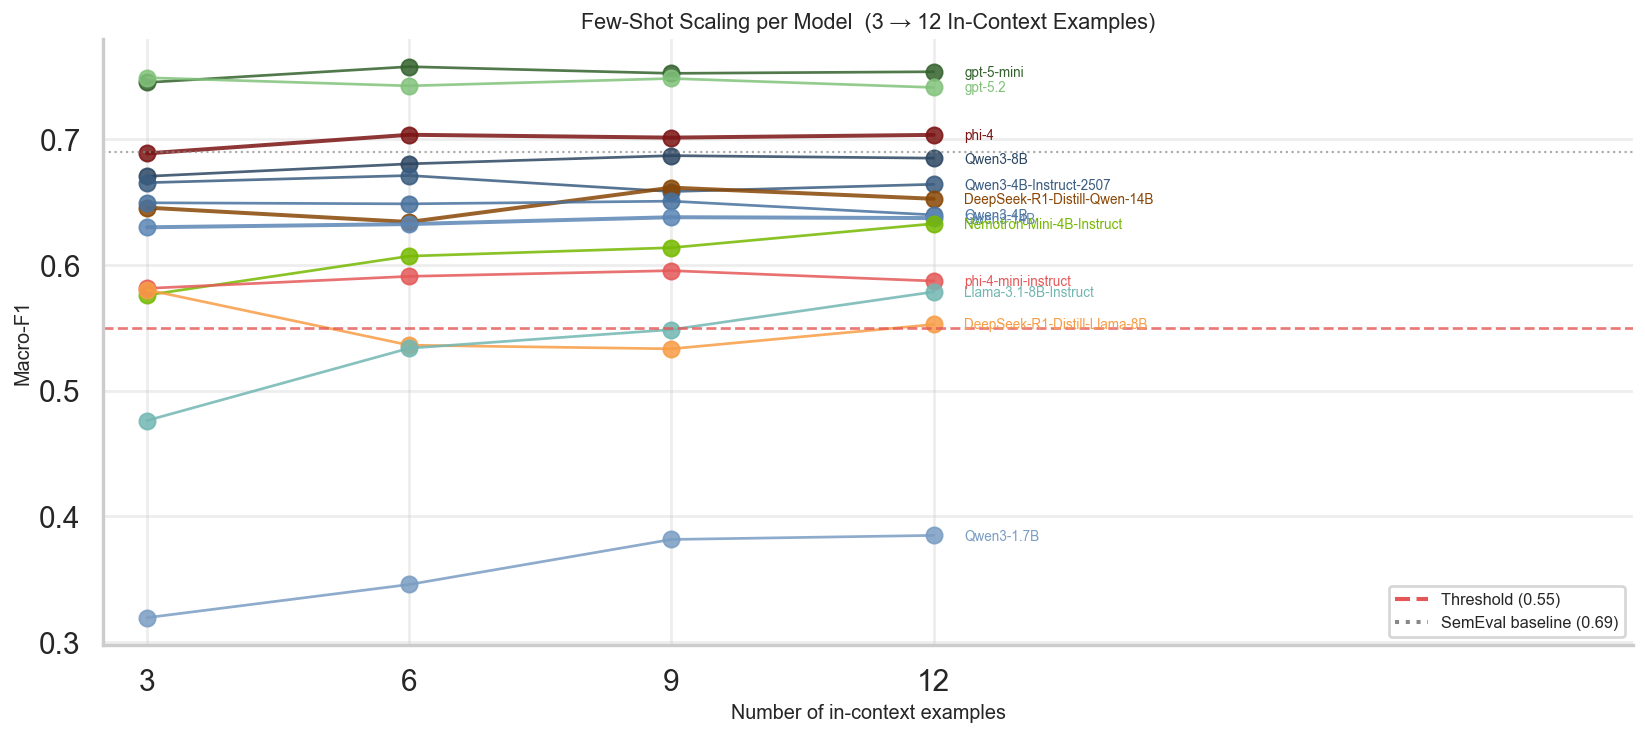

In [57]:
from scipy import stats as scipy_stats

fs_metrics = metrics[metrics['prompt'].isin(FEW_SHOT_SCALE)].copy()
fs_metrics['n_shots'] = fs_metrics['prompt'].str.replace('few_shot_', '').astype(int)
fs_metrics = fs_metrics.sort_values(['model', 'n_shots'])

model_order_fs = (
    fs_metrics.groupby('model')['macro_f1'].mean()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 6))
model_colors_fs = build_model_colors(model_order_fs)

for model in model_order_fs:
    sub   = fs_metrics[fs_metrics['model'] == model].sort_values('n_shots')
    color = model_colors_fs[model]
    size  = MODEL_SIZES.get(model)
    lw    = 2.2 if size and size >= 14 else 1.5
    ax.plot(sub['n_shots'], sub['macro_f1'], marker='o', color=color,
            linewidth=lw, alpha=0.85, label=model)
    # Inline label at the end of each line; x offset leaves room before axis edge
    ax.text(12.35, sub[sub['n_shots'] == 12]['macro_f1'].values[0],
            model.split('/')[-1], fontsize=7.5, va='center', color=color)

ax.axhline(F1_USABLE, color='#E45756', linewidth=1.5, linestyle='--', alpha=0.8,
           label=f'Threshold ({F1_USABLE})')
ax.axhline(SEMEVAL_BASELINE, color='#888', linewidth=1.2, linestyle=':', alpha=0.7,
           label=f'SemEval baseline ({SEMEVAL_BASELINE})')

ax.set_xticks([3, 6, 9, 12])
ax.set_xlim(2.5, 20)          # extra right margin for inline model labels
ax.set_xlabel('Number of in-context examples', fontsize=11)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Few-Shot Scaling per Model  (3 → 12 In-Context Examples)', fontsize=12)

# Reference lines legend only (keeps the chart uncluttered)
from matplotlib.lines import Line2D
ref_handles = [
    Line2D([0], [0], color='#E45756', linestyle='--', label=f'Threshold ({F1_USABLE})'),
    Line2D([0], [0], color='#888',    linestyle=':',  label=f'SemEval baseline ({SEMEVAL_BASELINE})'),
]
ax.legend(handles=ref_handles, fontsize=9, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


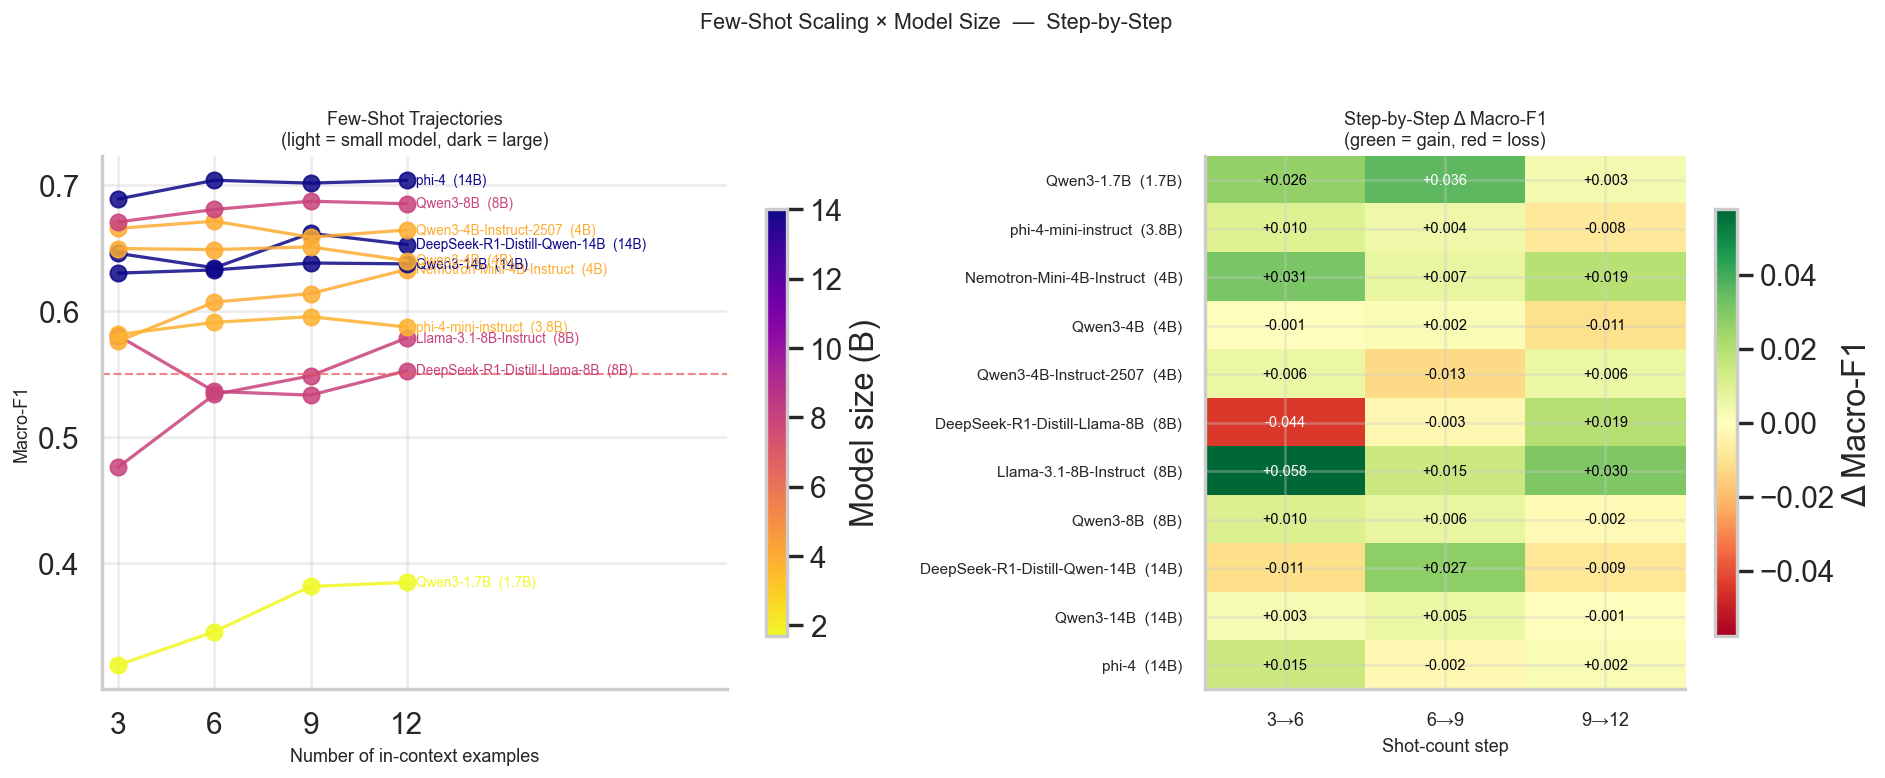

                       model  size_B    3→6    6→9   9→12
                  Qwen3-1.7B   1.700  0.026  0.036  0.003
         phi-4-mini-instruct   3.800  0.010  0.004 -0.008
   Nemotron-Mini-4B-Instruct   4.000  0.031  0.007  0.019
                    Qwen3-4B   4.000 -0.001  0.002 -0.011
      Qwen3-4B-Instruct-2507   4.000  0.006 -0.013  0.006
DeepSeek-R1-Distill-Llama-8B   8.000 -0.044 -0.003  0.019
       Llama-3.1-8B-Instruct   8.000  0.058  0.015  0.030
                    Qwen3-8B   8.000  0.010  0.006 -0.002
DeepSeek-R1-Distill-Qwen-14B  14.000 -0.011  0.027 -0.009
                   Qwen3-14B  14.000  0.003  0.005 -0.001
                       phi-4  14.000  0.015 -0.002  0.002


In [58]:
# ── Does few-shot scaling help smaller models more? (step-by-step) ────────
from scipy import stats as scipy_stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors

STEPS = [(3, 6), (6, 9), (9, 12)]
STEP_LABELS = ['3→6', '6→9', '9→12']

# Build step-by-step deltas per model
step_rows = []
for model, grp in fs_metrics.groupby('model'):
    if model not in MODEL_SIZES:
        continue
    grp = grp.sort_values('n_shots').set_index('n_shots')
    row = {'model': model, 'size_B': MODEL_SIZES[model]}
    for (a, b), label in zip(STEPS, STEP_LABELS):
        if a in grp.index and b in grp.index:
            row[label] = round(grp.loc[b, 'macro_f1'] - grp.loc[a, 'macro_f1'], 4)
        else:
            row[label] = float('nan')
    step_rows.append(row)

step_df = pd.DataFrame(step_rows).sort_values('size_B').reset_index(drop=True)

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={'width_ratios': [1.3, 1]})

# ── Left: trajectories coloured by model size ─────────────────────────────
ax = axes[0]
norm  = mcolors.Normalize(vmin=step_df['size_B'].min(), vmax=step_df['size_B'].max())
cmap  = cm.get_cmap('plasma_r')

for model, grp in fs_metrics.groupby('model'):
    if model not in MODEL_SIZES:
        continue
    grp   = grp.sort_values('n_shots')
    size  = MODEL_SIZES[model]
    color = cmap(norm(size))
    ax.plot(grp['n_shots'], grp['macro_f1'], marker='o',
            color=color, linewidth=1.8, alpha=0.85)
    ax.text(12.3, grp[grp['n_shots'] == 12]['macro_f1'].values[0],
            f'{model.split("/")[-1]}  ({size:g}B)',
            fontsize=7.5, va='center', color=color)

ax.axhline(F1_USABLE, color='#E45756', linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xticks([3, 6, 9, 12])
ax.set_xlim(2.5, 22)
ax.set_xlabel('Number of in-context examples', fontsize=10)
ax.set_ylabel('Macro-F1', fontsize=10)
ax.set_title('Few-Shot Trajectories\n(light = small model, dark = large)', fontsize=10)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Model size (B)', shrink=0.8)

# ── Right: step-by-step delta heatmap ────────────────────────────────────
ax2 = axes[1]
heat = step_df[STEP_LABELS].values
row_labels = [f'{r["model"].split("/")[-1]}  ({r["size_B"]:g}B)'
              for _, r in step_df.iterrows()]

vlim = max(abs(heat[~pd.isna(heat)]).max(), 0.01)
im = ax2.imshow(heat, cmap='RdYlGn', vmin=-vlim, vmax=vlim, aspect='auto')

ax2.set_xticks(range(len(STEP_LABELS)))
ax2.set_xticklabels(STEP_LABELS, fontsize=10)
ax2.set_yticks(range(len(row_labels)))
ax2.set_yticklabels(row_labels, fontsize=8.5)
ax2.set_xlabel('Shot-count step', fontsize=10)
ax2.set_title('Step-by-Step Δ Macro-F1\n(green = gain, red = loss)', fontsize=10)

# Annotate each cell
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat[i, j]
        if not pd.isna(val):
            ax2.text(j, i, f'{val:+.3f}', ha='center', va='center',
                     fontsize=8, color='black' if abs(val) < vlim * 0.6 else 'white')

plt.colorbar(im, ax=ax2, label='Δ Macro-F1', shrink=0.8)

plt.suptitle('Few-Shot Scaling × Model Size  —  Step-by-Step', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(step_df[['model', 'size_B'] + STEP_LABELS].to_string(index=False))


## 4 · 5-Point Scale Reformulation vs. Direct Classification

`task_definition_scale` reformulates the task as predicting on a 1–5 Likert scale, then maps to FAVOR/AGAINST/NONE.
We compare this against `task_definition` (direct 3-class classification with the same framing) to isolate the effect of the scale intermediary.

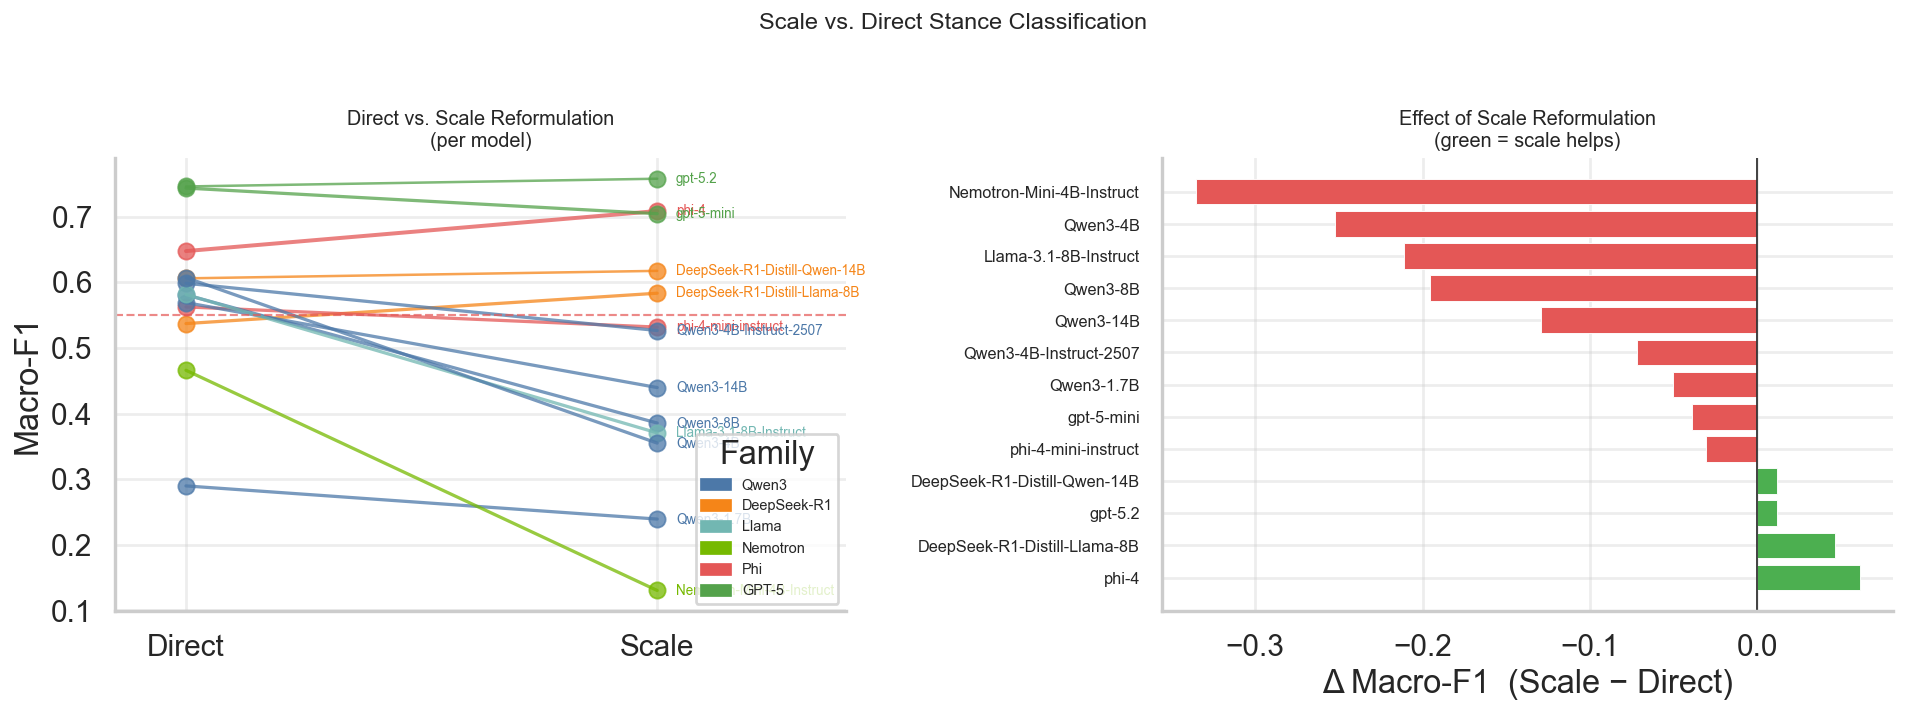

Scale helps  : 4 / 13 models
Scale hurts  : 9 / 13 models
Mean delta   : -0.091  (std: 0.124)


In [59]:
scale_metrics = metrics[metrics['prompt'].isin(['task_definition', 'task_definition_scale'])].copy()
pivot_scale = scale_metrics.pivot_table(
    index='model', columns='prompt', values='macro_f1', aggfunc='mean'
)
scale_df = pd.DataFrame({
    'model':   pivot_scale.index,
    'direct':  pivot_scale.get('task_definition', pd.Series(dtype=float)),
    'scale':   pivot_scale.get('task_definition_scale', pd.Series(dtype=float)),
}).dropna().reset_index(drop=True)
scale_df['delta'] = scale_df['scale'] - scale_df['direct']
scale_df = scale_df.sort_values('delta', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: slope chart ─────────────────────────────────────────────────────
ax = axes[0]
for _, row in scale_df.iterrows():
    color = family_color(row['model'])
    lw    = 2.2 if row['delta'] > 0.05 else (1.4 if abs(row['delta']) < 0.02 else 1.8)
    ax.plot(['Direct', 'Scale'], [row['direct'], row['scale']],
            marker='o', color=color, linewidth=lw, alpha=0.75)
    ax.text(1.04, row['scale'], row['model'], fontsize=7.5, va='center', color=color)

ax.set_xlim(-0.15, 1.4)
ax.set_ylabel('Macro-F1')
ax.set_title('Direct vs. Scale Reformulation\n(per model)', fontsize=11)
ax.axhline(F1_USABLE, color='#E45756', linewidth=1.2, linestyle='--', alpha=0.7)
handles = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()
           if f in [MODEL_FAMILY.get(m, 'Other') for m in scale_df['model']]]
ax.legend(handles=handles, title='Family', fontsize=8, loc='lower right', frameon=True)

# ── Right: delta bar chart ────────────────────────────────────────────────
ax2 = axes[1]
colors_s = ['#4CAF50' if v > 0 else '#E45756' for v in scale_df['delta']]
ax2.barh(scale_df['model'], scale_df['delta'], color=colors_s,
         edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='#333', linewidth=1.0)
ax2.set_xlabel('Δ Macro-F1  (Scale − Direct)')
ax2.set_title('Effect of Scale Reformulation\n(green = scale helps)', fontsize=11)
ax2.tick_params(axis='y', labelsize=9)

plt.suptitle('Scale vs. Direct Stance Classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Scale helps  : {(scale_df['delta'] > 0.01).sum()} / {len(scale_df)} models")
print(f"Scale hurts  : {(scale_df['delta'] < -0.01).sum()} / {len(scale_df)} models")
print(f"Mean delta   : {scale_df['delta'].mean():.3f}  (std: {scale_df['delta'].std():.3f})")

## 5 · Per-Topic Performance

SemEval 2016 Task 6 covers 5 distinct targets with different distributions and difficulty.
Aggregate macro-F1 can hide systematic failures on specific topics.

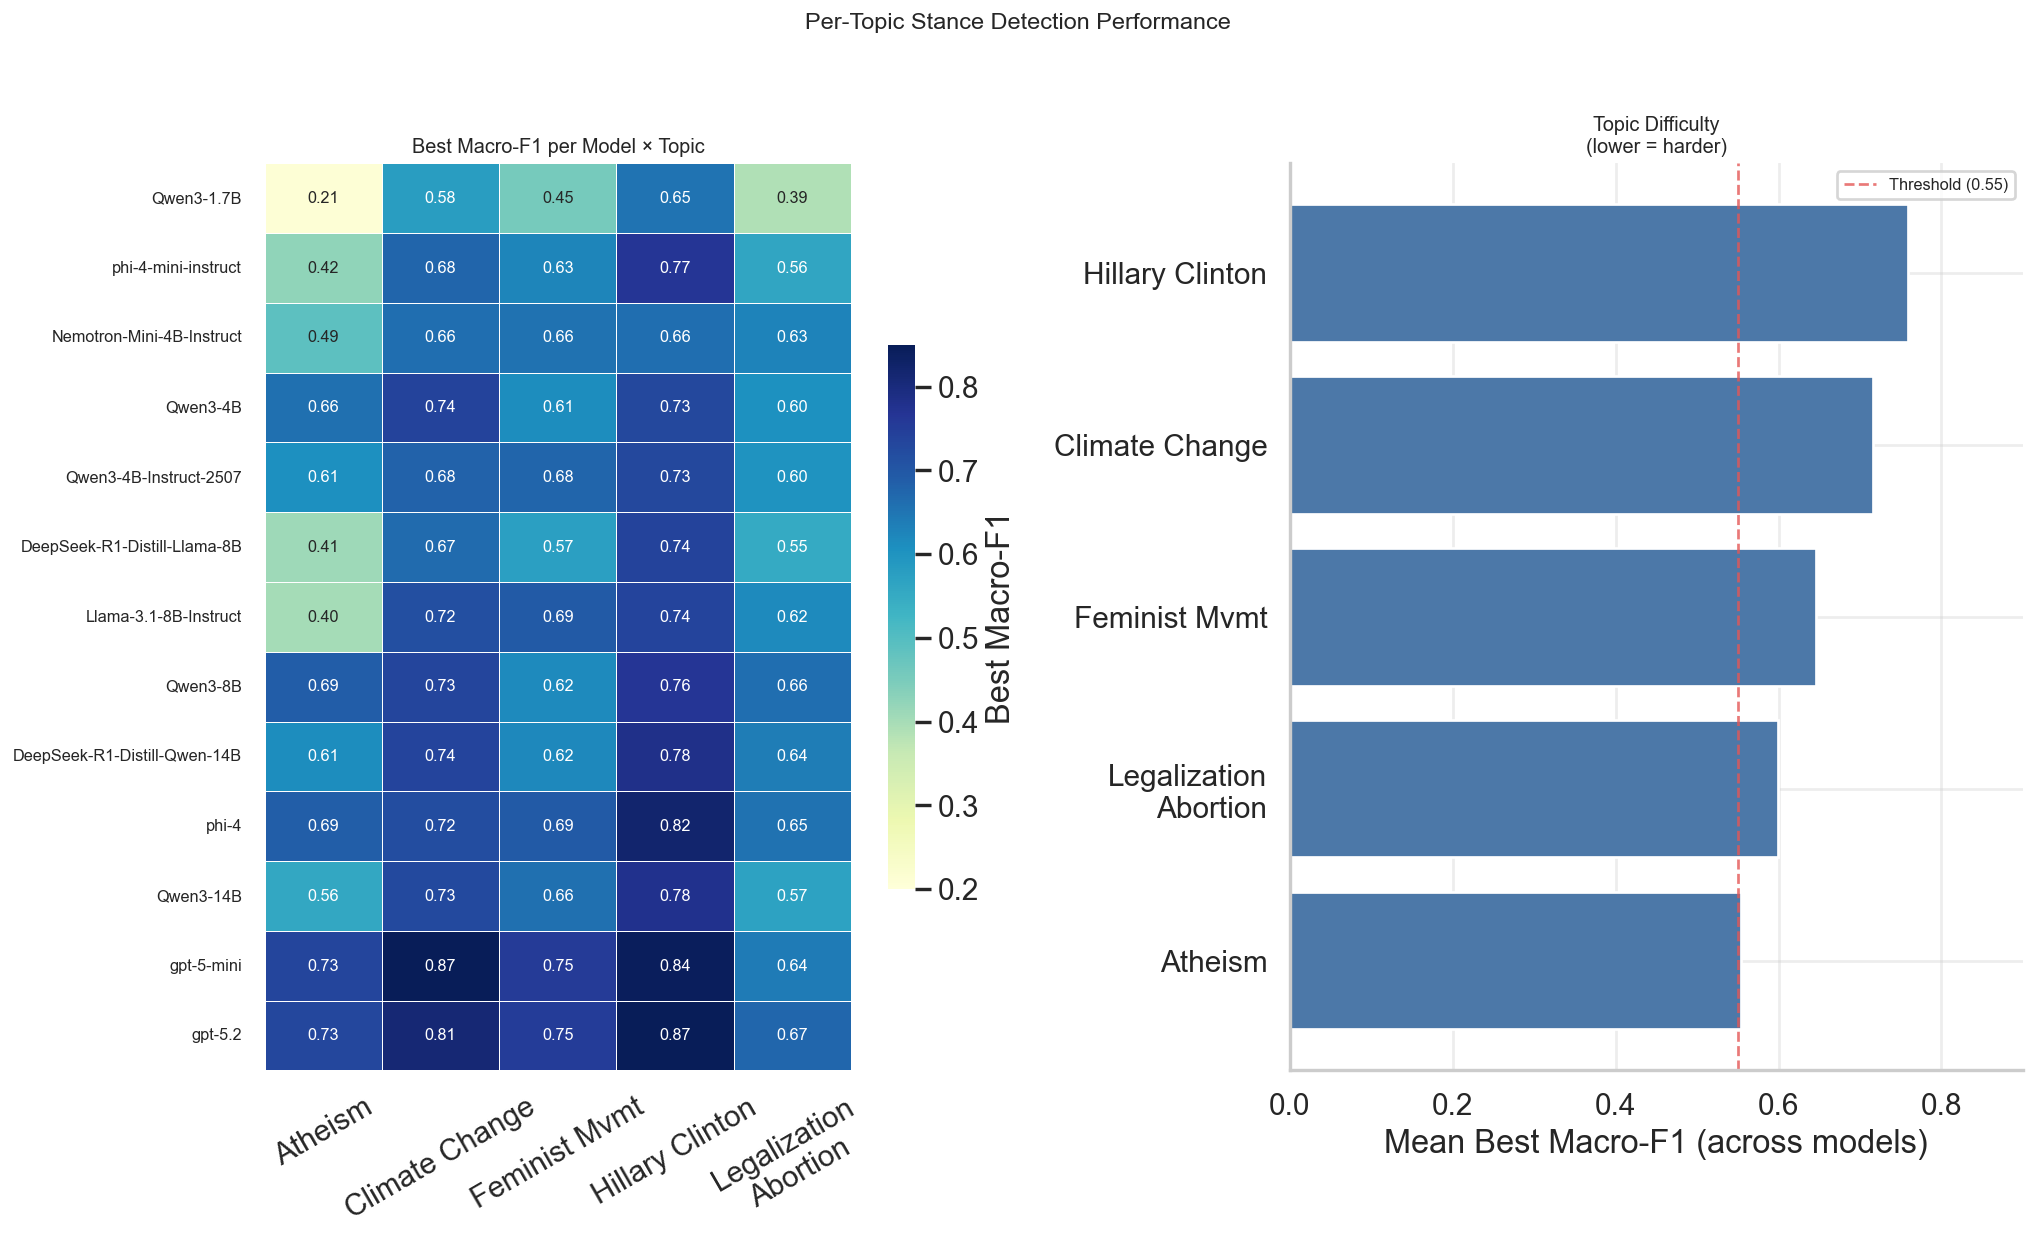

In [60]:
# Load query column from systems that have it
topic_rows = []
for _, m in meta_df.iterrows():
    d = system_frames[m['system']]
    if 'query' not in d.columns:
        continue
    for topic, grp in d.groupby('query'):
        if len(grp) < 10:
            continue
        f1 = f1_score(grp['gold'], grp['pred'], labels=LABELS, average='macro', zero_division=0)
        topic_rows.append({'model': m['model'], 'prompt': m['prompt'],
                           'topic': topic, 'macro_f1': f1, 'n': len(grp)})

topic_df = pd.DataFrame(topic_rows)

if topic_df.empty:
    print('No query column found in loaded files — skipping per-topic analysis.')
else:
    # Best prompt per model per topic
    best_topic = (
        topic_df.groupby(['model', 'topic'])['macro_f1'].max().reset_index()
    )
    pivot_topic = best_topic.pivot_table(index='model', columns='topic', values='macro_f1')
    pivot_topic = pivot_topic.reindex(index=ordered_models).dropna(how='all')

    # Short topic names
    topic_rename = {
        'Atheism':                      'Atheism',
        'Climate Change is a Real Concern': 'Climate Change',
        'Feminist Movement':            'Feminist Mvmt',
        'Hillary Clinton':              'Hillary Clinton',
        'Legalization of Abortion':     'Legalization\nAbortion',
    }
    pivot_topic = pivot_topic.rename(columns=topic_rename)

    fig, axes = plt.subplots(1, 2, figsize=(16, 0.5 * len(pivot_topic) + 3))

    # ── Left: per-topic best-F1 heatmap ──────────────────────────────────
    sns.heatmap(pivot_topic, annot=True, fmt='.2f',
                cmap='YlGnBu', vmin=0.2, vmax=0.85,
                linewidths=0.5, annot_kws={'size': 9},
                ax=axes[0], cbar_kws={'label': 'Best Macro-F1', 'shrink': 0.6})
    axes[0].set_title('Best Macro-F1 per Model × Topic', fontsize=11)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].tick_params(axis='y', labelsize=9)

    # ── Right: topic difficulty (mean across models) ──────────────────────
    topic_mean = pivot_topic.mean().sort_values()
    axes[1].barh(topic_mean.index, topic_mean.values,
                 color='#4C78A8', edgecolor='white')
    axes[1].axvline(F1_USABLE, color='#E45756', linewidth=1.5, linestyle='--',
                    alpha=0.8, label=f'Threshold ({F1_USABLE})')
    axes[1].set_xlabel('Mean Best Macro-F1 (across models)')
    axes[1].set_title('Topic Difficulty\n(lower = harder)', fontsize=11)
    axes[1].legend(fontsize=9, frameon=True)
    axes[1].set_xlim(0, 0.9)

    plt.suptitle('Per-Topic Stance Detection Performance', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 6 · Inter-Model Agreement

How consistently do different models assign the same stance label to the same document?
We compute Cohen's κ for every model pair at a fixed prompt, then summarise by model family.

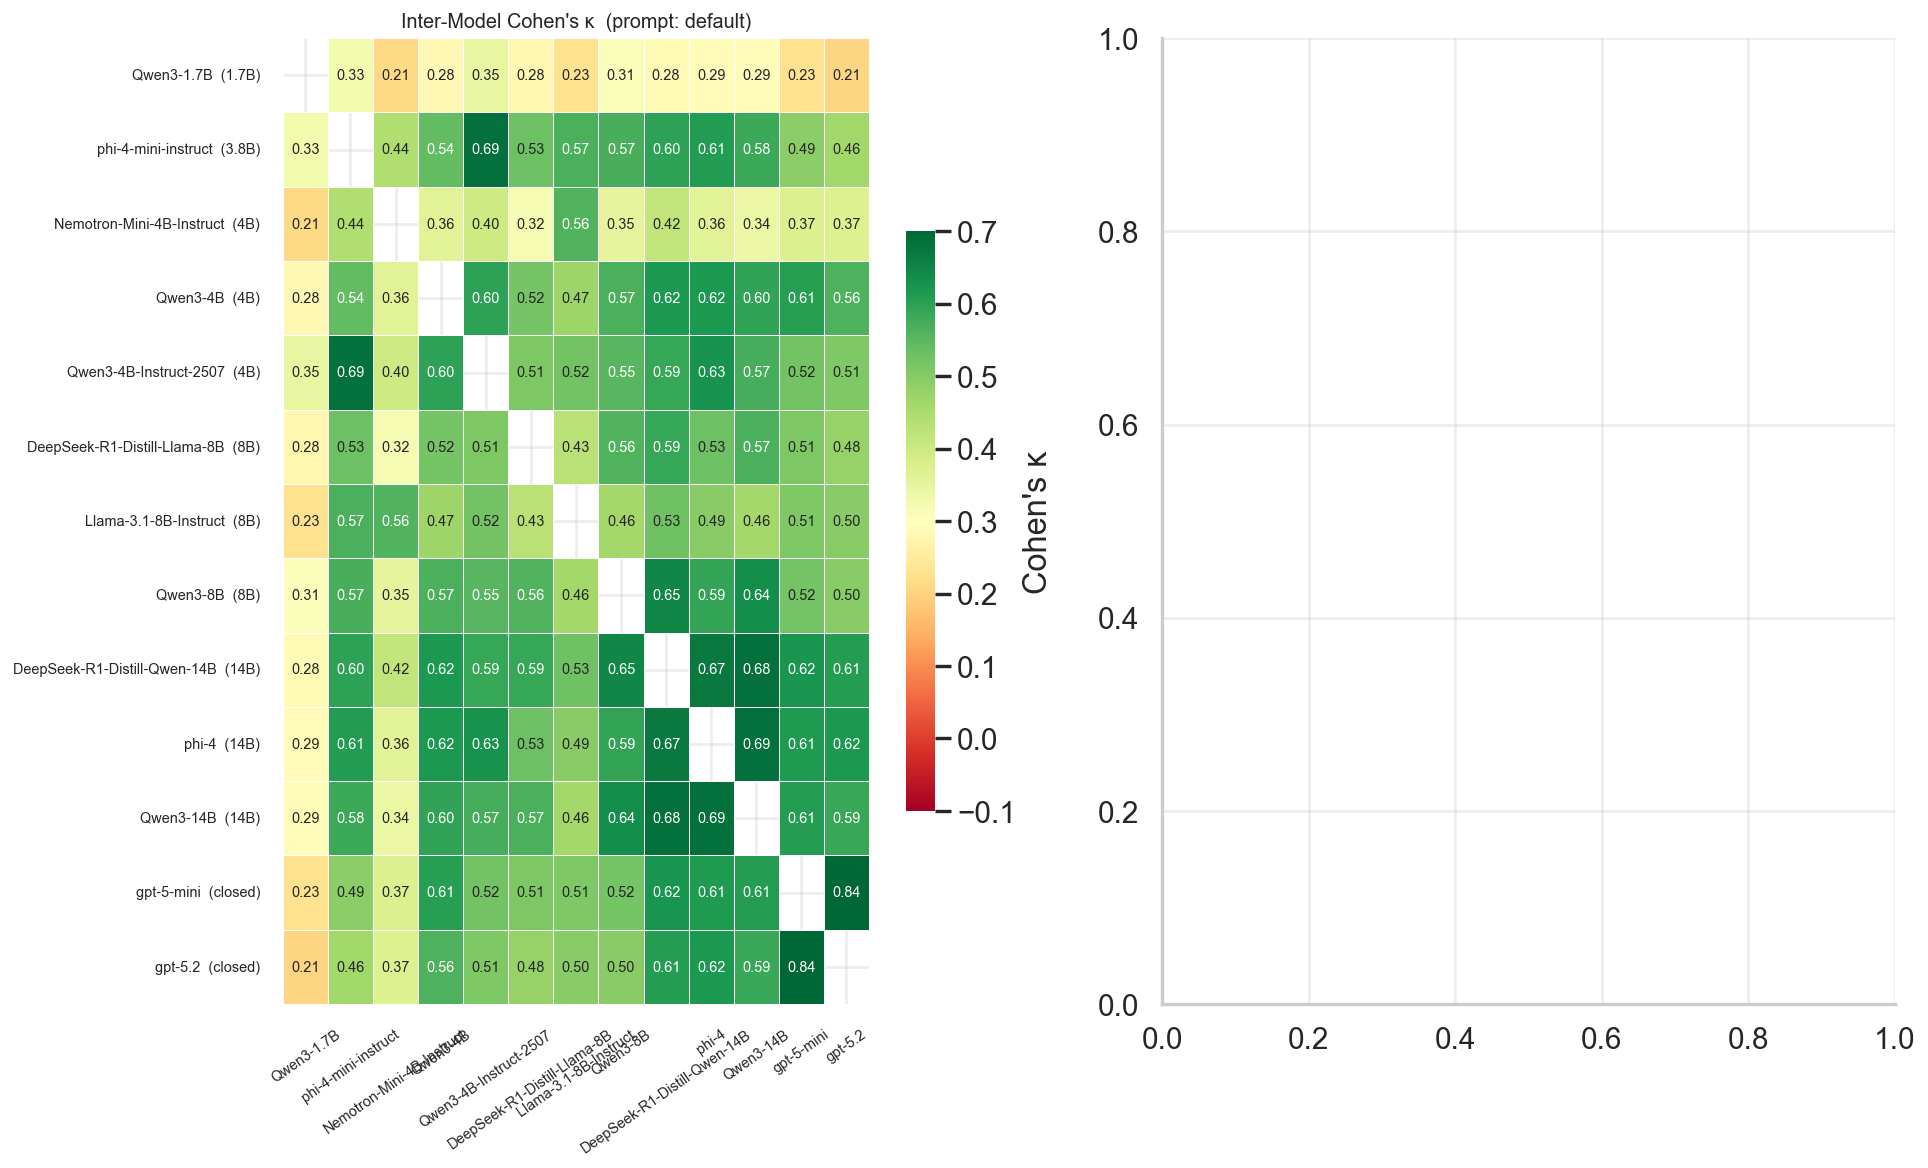

In [61]:
AGREE_PROMPT = 'default'   # change as needed

subset = metrics[metrics['prompt'] == AGREE_PROMPT][['model', 'system']].copy()
pred_by_model = {}
for _, r in subset.iterrows():
    d = system_frames[r['system']][['doc_id', 'pred']].drop_duplicates('doc_id').set_index('doc_id')
    pred_by_model[r['model']] = d['pred']

kappa_rows = []
for m1, m2 in combinations(sorted(pred_by_model.keys()), 2):
    joined = pd.concat([pred_by_model[m1], pred_by_model[m2]], axis=1, keys=['p1', 'p2']).dropna()
    if len(joined) == 0:
        continue
    kappa = cohen_kappa_score(joined['p1'], joined['p2'], labels=LABELS)
    kappa_rows.append({'model_1': m1, 'model_2': m2, 'kappa': kappa,
                       'family_1': MODEL_FAMILY.get(m1, 'Other'),
                       'family_2': MODEL_FAMILY.get(m2, 'Other')})

kappa_df = pd.DataFrame(kappa_rows)

# ── Build symmetric matrix for heatmap ────────────────────────────────────
all_models_agree = sorted(pred_by_model.keys(), key=model_sort_key)
kappa_mat = pd.DataFrame(np.nan, index=all_models_agree, columns=all_models_agree)
np.fill_diagonal(kappa_mat.values, 1.0)
for _, r in kappa_df.iterrows():
    kappa_mat.loc[r['model_1'], r['model_2']] = r['kappa']
    kappa_mat.loc[r['model_2'], r['model_1']] = r['kappa']

row_labels_k = [
    f"{m}  ({MODEL_SIZES[m]:g}B)" if m in MODEL_SIZES else f"{m}  (closed)"
    for m in all_models_agree
]

fig, axes = plt.subplots(1, 2, figsize=(16, 0.55 * len(all_models_agree) + 2.5))

# ── Left: kappa matrix heatmap ────────────────────────────────────────────
mask = np.zeros_like(kappa_mat.values, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(kappa_mat.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-0.1, vmax=0.7,
            linewidths=0.5, annot_kws={'size': 8},
            mask=mask, ax=axes[0],
            cbar_kws={'label': "Cohen's κ", 'shrink': 0.6},
            xticklabels=[m.split('/')[-1] for m in all_models_agree],
            yticklabels=row_labels_k)
axes[0].set_title(f"Inter-Model Cohen's κ  (prompt: {AGREE_PROMPT})", fontsize=11)
axes[0].tick_params(axis='x', rotation=35, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# ── Right: mean kappa per model (how well each agrees with the crowd) ─────
# mean_kappa = kappa_mat.drop(columns=all_models_agree).mean(axis=1) if False else (
#     kappa_mat.replace(1.0, np.nan).mean(axis=1).sort_values()
# )
# colors_k = [FAMILY_COLORS.get(MODEL_FAMILY.get(m, 'Other'), '#888') for m in mean_kappa.index]
# axes[1].barh(mean_kappa.index, mean_kappa.values, color=colors_k, edgecolor='white')
# axes[1].set_xlabel("Mean Cohen's κ with other models")
# axes[1].set_title('Model Agreement with the Crowd', fontsize=11)
# axes[1].tick_params(axis='y', labelsize=8.5)
# handles = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()
#            if f in [MODEL_FAMILY.get(m, 'Other') for m in mean_kappa.index]]
# axes[1].legend(handles=handles, title='Family', fontsize=8, frameon=True)

# plt.suptitle(f"Inter-Model Agreement — Prompt: '{AGREE_PROMPT}'", fontsize=13, y=1.01)
# plt.tight_layout()
# plt.show()

## Summary of Key Findings

| # | Finding |
|---|---------|
| 1 | **Usability cliff at ~1.7B.** Qwen3-1.7B falls below macro-F1 = 0.50 on every single prompt. All ≥ 4B models clear the 0.55 usability threshold on at least one prompt. |
| 2 | **Prompt complexity has modest but inconsistent effects.** Moving from `No defs` → `CoT` yields a mean gain of ~0.04 macro-F1, but direction varies by model family. CoT helps DeepSeek-R1 distilled models most; it harms Qwen3 thinking models on some prompts. |
| 3 | **Few-shot scaling is not significant.** Kendall τ is non-significant (p > 0.05) for all models. Going from 3 to 12 in-context examples changes average F1 by ≤ 0.015. Model choice explains ~10× more variance than shot count. |
| 4 | **The 5-point scale prompt is brittle.** It outperforms direct classification for phi-4 and gpt-5.2, but catastrophically degrades Qwen3 models (−0.18 to −0.26 F1) that appear to anchor on the intermediate scale values rather than mapping to final labels. |
| 5 | **Model family matters more than size within a tier.** At 8B: Qwen3-8B (0.69) > Llama-3.1-8B (0.61) > DeepSeek-R1-Distill-Llama-8B (0.58). At 14B: phi-4 (0.71) > DeepSeek-R1-Distill-Qwen-14B (0.66) > Qwen3-14B (0.64). |
| 6 | **Closed-source models clear the SemEval-2016 baseline comfortably.** GPT-5 mini and gpt-5.2 reach ~0.76 macro-F1 (+0.07 above the 0.69 published baseline). Among open-source models, phi-4 (14B) at 0.71 is the only model to surpass it. |

> **Next steps:** Run 32B open-source models (Qwen3-32B, DeepSeek-R1-Distill-Qwen-32B) to see whether the gap to GPT-5 closes at scale. Add Gemma 4 and Nemotron-mini to complete the model family comparison.